In [ ]:
# ── STEP 1: Install dependencies & mount Drive ──────────────────────────────
!pip install numpy==1.23.5 -q
!pip install gensim -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ── Load dataset (upload financial_phrase.csv when prompted) ─────────────────
from google.colab import files
uploaded = files.upload()   # upload your financial_phrase.csv here

df = pd.read_csv('financial_phrase.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nNull values:", df.isnull().sum().to_dict())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 49.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.7 MB/s eta 0:00:00


Saving financial_phrase.csv to financial_phrase.csv
Shape: (2264, 2)

First 5 rows:
                                                text     label
0  According to Gran , the company has no plans t...   neutral
1  For the last quarter of 2010 , Componenta 's n...  positive
2  In the third quarter of 2010 , net sales incre...  positive
3  Operating profit rose to EUR 13.1 mn from EUR ...  positive
4  Operating profit totalled EUR 21.1 mn , up fro...  positive

Column names: ['text', 'label']

Label distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

Null values: {'text': 0, 'label': 0}


In [ ]:
# ── STEP 2: Text Preprocessing ───────────────────────────────────────────────
import re
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                                      # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)              # remove URLs
    text = re.sub(r'@\w+', '', text)                        # remove mentions
    text = re.sub(r'#\w+', '', text)                        # remove hashtags
    text = re.sub(r'\d+', '', text)                         # remove numbers
    text = re.sub(r'[^\w\s]', '', text)                     # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra spaces

    # remove stopwords & lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# Remove duplicates first
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f"After removing duplicates: {len(df)} rows")

# Apply cleaning
df['cleaned'] = df['text'].apply(clean_text)

# Encode labels
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label_enc'] = df['label'].map(label_map)

# Preview
print("\nSample cleaned text:")
print(df[['text', 'cleaned', 'label']].head(3).to_string())

print("\nCleaned text stats:")
df['word_count'] = df['cleaned'].apply(lambda x: len(x.split()))
print(df.groupby('label')['word_count'].describe().round(2))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


After removing duplicates: 2259 rows

Sample cleaned text:
                                                                                                                                                                                                text                                                                                                           cleaned     label
0                                                                    According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .                                       according gran company plan move production russia although company growing   neutral
1  For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .  last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit preta

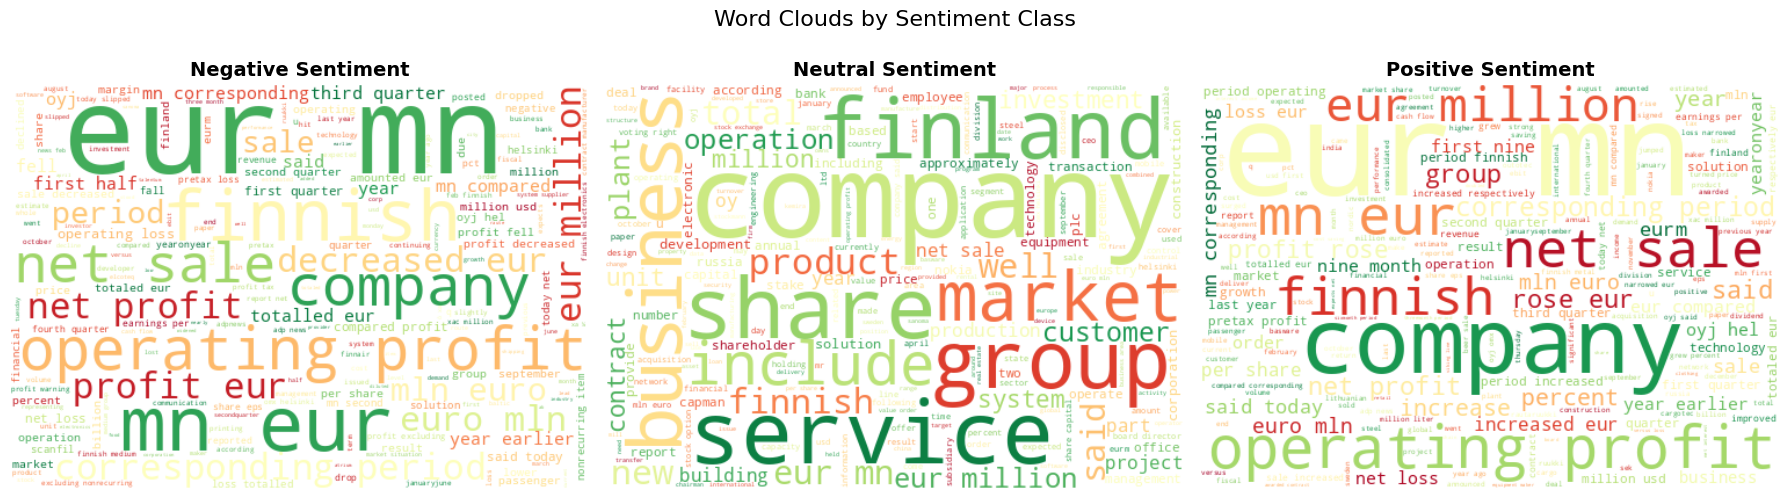

Word clouds saved!


In [ ]:
# ── STEP 2b: Visualizations ───────────────────────────────────────────────────
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, sentiment in zip(axes, ['negative', 'neutral', 'positive']):
    text_blob = ' '.join(df[df['label'] == sentiment]['cleaned'])
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap='RdYlGn').generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{sentiment.capitalize()} Sentiment', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Sentiment Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Word clouds saved!")

In [ ]:
lengths = df['cleaned'].apply(lambda x: len(x.split()))
MAX_LEN = int(np.percentile(lengths, 95)) # 95th percentile of sentence lengths

In [ ]:
# ── STEP 3: Tokenization, Padding & Train/Test Split ─────────────────────────
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = df['cleaned'].values
y = df['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"\nTrain label distribution: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Test  label distribution: {dict(zip(*np.unique(y_test,  return_counts=True)))}")

VOCAB_SIZE = 5000
tokenizer  = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

lengths = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"\n95th percentile sequence length → MAX_LEN = {MAX_LEN}")
print(f"Vocabulary size (fitted)        → {len(tokenizer.word_index)} unique tokens")

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")
print(f"\nSample padded sequence (first 15 values):\n{X_train_pad[0][:15]}")

Training samples : 1807
Test samples     : 452

Train label distribution: {np.int64(0): np.int64(242), np.int64(1): np.int64(1109), np.int64(2): np.int64(456)}
Test  label distribution: {np.int64(0): np.int64(61), np.int64(1): np.int64(277), np.int64(2): np.int64(114)}

95th percentile sequence length → MAX_LEN = 22
Vocabulary size (fitted)        → 4405 unique tokens

X_train_pad shape : (1807, 22)
X_test_pad  shape : (452, 22)

Sample padded sequence (first 15 values):
[ 104   39    7   16   28  512  105    2  317   22 1374    2    0    0
    0]


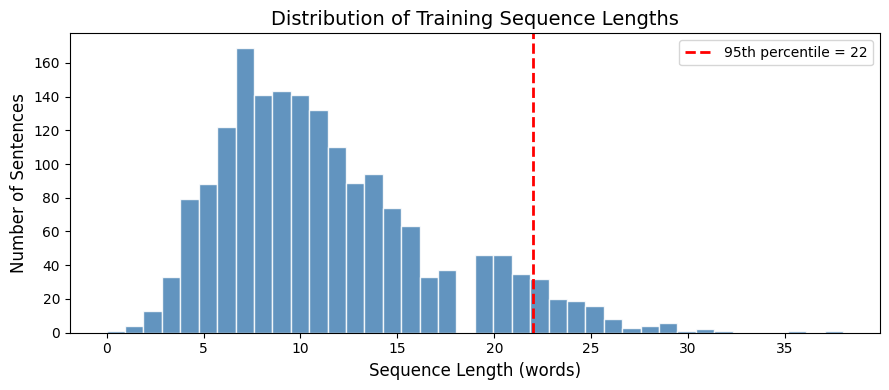

Plot saved!


In [ ]:
# ── STEP 3b: Sequence length distribution plot ────────────────────────────────
plt.figure(figsize=(9, 4))
plt.hist(lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {MAX_LEN}')
plt.xlabel('Sequence Length (words)', fontsize=12)
plt.ylabel('Number of Sentences', fontsize=12)
plt.title('Distribution of Training Sequence Lengths', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('seq_length_dist.png', dpi=150)
plt.show()
print("Plot saved!")

In [ ]:
# ── STEP 4: Model 1 - Simple RNN ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

NUM_CLASSES  = 3
EMBED_DIM    = 64

# ── Build Model ───────────────────────────────────────────────────────────────
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='Simple_RNN')

rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Model 1 ─────────────────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete!")
print(f"Best val_accuracy : {max(history_rnn.history['val_accuracy']):.4f}")

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6771 - loss: 0.8200 - val_accuracy: 0.7403 - val_loss: 0.6491
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7780 - loss: 0.5308 - val_accuracy: 0.7956 - val_loss: 0.5855
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8327 - loss: 0.4020 - val_accuracy: 0.7348 - val_loss: 0.5874
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8739 - loss: 0.2929 - val_accuracy: 0.7901 - val_loss: 0.5651
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9207 - loss: 0.1927 - val_accuracy: 0.7624 - val_loss: 0.6664
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9606 - loss: 0.1224 - val_accuracy: 0.7956 - val_loss: 0.6010
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9686 - loss: 0.0912 - val_accuracy: 0.7790 - val_loss: 0.7107

Training complete!
Best val_accuracy : 0.7956


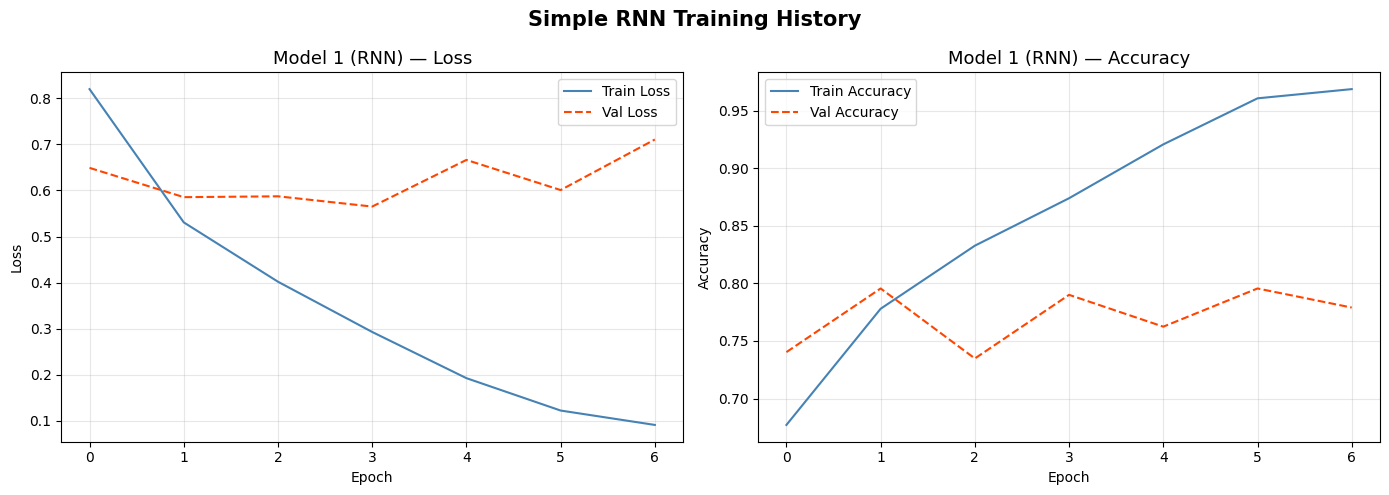

Plot saved!


In [ ]:
# ── Plot RNN Training Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history['loss'],     label='Train Loss',     color='steelblue')
axes[0].plot(history_rnn.history['val_loss'], label='Val Loss',       color='orangered', linestyle='--')
axes[0].set_title('Model 1 (RNN) — Loss',     fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_rnn.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history_rnn.history['val_accuracy'], label='Val Accuracy',   color='orangered', linestyle='--')
axes[1].set_title('Model 1 (RNN) — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Simple RNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_training.png', dpi=150)
plt.show()
print("Plot saved!")

In [ ]:
# ── STEP 5: Model 2 - LSTM ────────────────────────────────────────────────────
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Model')

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Train Model 2 ─────────────────────────────────────────────────────────────
early_stop2 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

print("\nTraining complete!")
print(f"RNN  best val_accuracy : {max(history_rnn.history['val_accuracy']):.4f}")
print(f"LSTM best val_accuracy : {max(history_lstm.history['val_accuracy']):.4f}")

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5849 - loss: 0.9710 - val_accuracy: 0.6575 - val_loss: 0.8151
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7177 - loss: 0.6439 - val_accuracy: 0.7901 - val_loss: 0.5316
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8137 - loss: 0.4200 - val_accuracy: 0.8232 - val_loss: 0.4953
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8450 - loss: 0.3403 - val_accuracy: 0.8122 - val_loss: 0.5012
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8499 - loss: 0.3139 - val_accuracy: 0.8011 - val_loss: 0.5678
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8499 - loss: 0.3211 - val_accuracy: 0.7845 - val_loss: 0.5497

Training complete!
RNN  best val_accuracy : 0.7956
LSTM best val_accuracy : 0.8232


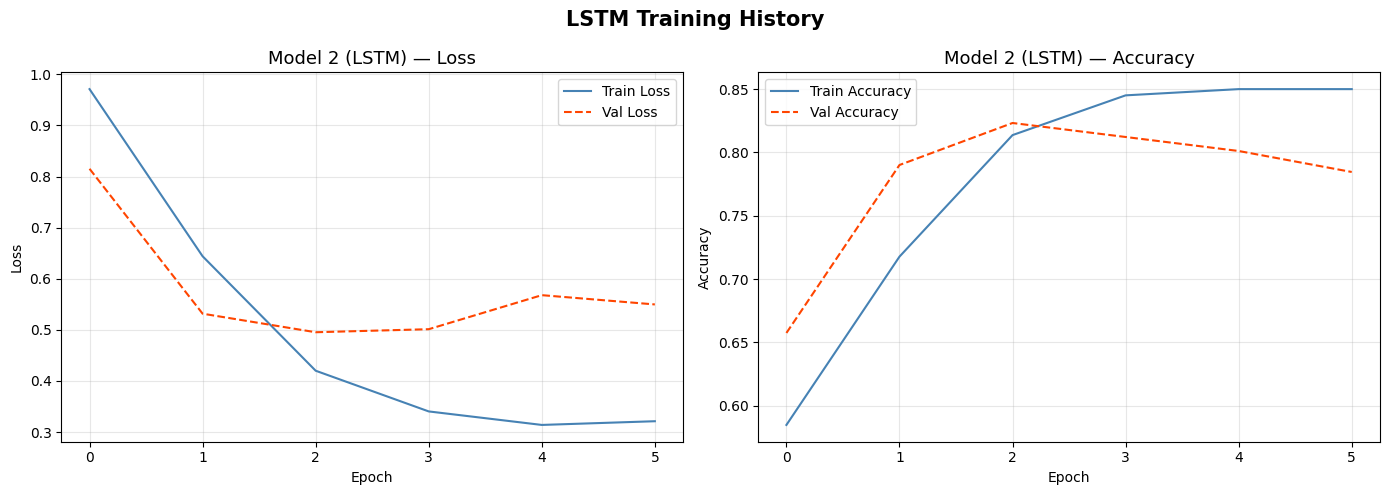

Plot saved!


In [ ]:
# ── Plot LSTM Training Curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history['loss'],     label='Train Loss',   color='steelblue')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss',     color='orangered', linestyle='--')
axes[0].set_title('Model 2 (LSTM) — Loss',     fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy',   color='orangered', linestyle='--')
axes[1].set_title('Model 2 (LSTM) — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training.png', dpi=150)
plt.show()
print("Plot saved!")

In [ ]:
# ── STEP 6: Load Word2Vec & Build Embedding Matrix ───────────────────────────
import gensim.downloader as api

print("Downloading GloVe embeddings... (this may take 2-3 minutes)")
embedding_model = api.load('glove-wiki-gigaword-50')  # 50-dimensional
print("Done! Embedding model loaded.")

EMBED_DIM_W2V = 50  # must match downloaded model

# Build embedding matrix
word_index    = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))

found, not_found = 0, 0
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"\nEmbedding matrix shape : {embedding_matrix.shape}")
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found        : {not_found}")
print(f"Coverage               : {found/(found+not_found)*100:.1f}%")

[==================================================] 100.0% 66.0/66.0MB downloaded
Done! Embedding model loaded.

Embedding matrix shape : (5000, 50)
Words found in GloVe   : 3797
Words NOT found        : 608
Coverage               : 86.2%


In [ ]:
# ── Build Model 3 ─────────────────────────────────────────────────────────────
from tensorflow.keras.layers import Embedding

lstm_w2v = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM_W2V,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=False),          # freeze pretrained weights
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name='LSTM_Word2Vec')

lstm_w2v.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_w2v.summary()

Model: "LSTM_Word2Vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       250,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 250,000 (976.56 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 250,000 (976.56 KB)

In [ ]:
# ── Train Model 3 ─────────────────────────────────────────────────────────────
early_stop3 = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_w2v = lstm_w2v.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop3],
    verbose=1
)

print("\nTraining complete!")
print(f"RNN        best val_accuracy : {max(history_rnn.history['val_accuracy']):.4f}")
print(f"LSTM       best val_accuracy : {max(history_lstm.history['val_accuracy']):.4f}")
print(f"LSTM+GloVe best val_accuracy : {max(history_w2v.history['val_accuracy']):.4f}")

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6581 - loss: 0.7966 - val_accuracy: 0.7514 - val_loss: 0.6181
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7448 - loss: 0.6104 - val_accuracy: 0.7735 - val_loss: 0.5540
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7595 - loss: 0.5642 - val_accuracy: 0.8011 - val_loss: 0.5241
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7589 - loss: 0.5317 - val_accuracy: 0.7624 - val_loss: 0.5160
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7743 - loss: 0.5176 - val_accuracy: 0.7845 - val_loss: 0.5300
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7706 - loss: 0.5063 - val_accuracy: 0.7790 - val_loss: 0.4747
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7866 - loss: 0.4647 - val_accuracy: 0.7790 - val_loss: 0.4703
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8026 - loss: 0.4353 - val_accuracy: 0.7901 - v

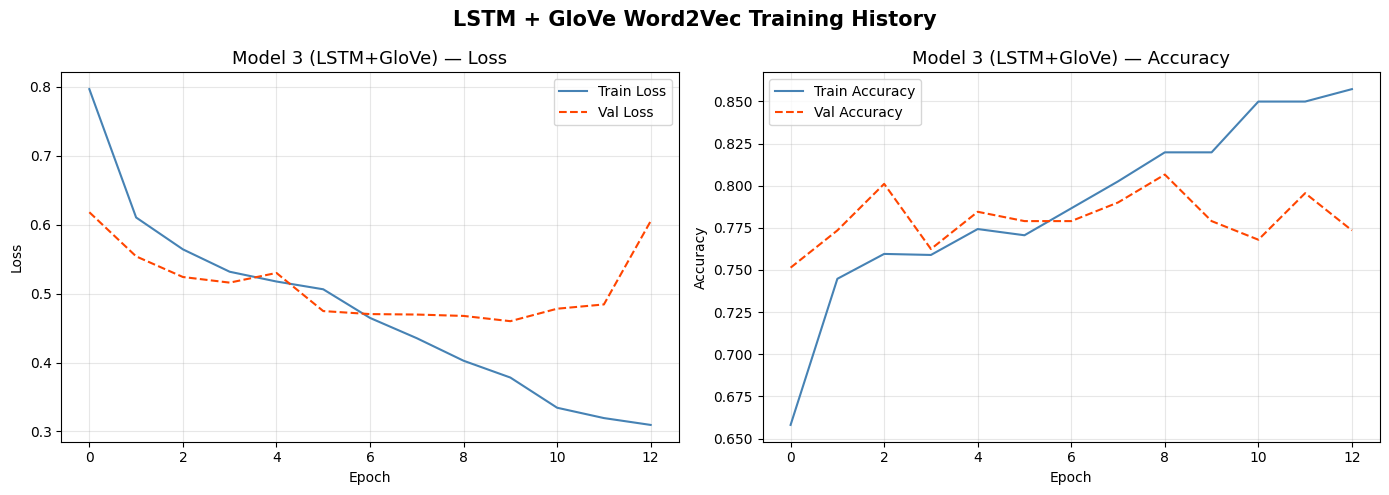

Plot saved!


In [ ]:
# ── Plot Model 3 Training Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_w2v.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(history_w2v.history['val_loss'], label='Val Loss',   color='orangered', linestyle='--')
axes[0].set_title('Model 3 (LSTM+GloVe) — Loss', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_w2v.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[1].plot(history_w2v.history['val_accuracy'], label='Val Accuracy',   color='orangered', linestyle='--')
axes[1].set_title('Model 3 (LSTM+GloVe) — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('LSTM + GloVe Word2Vec Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_w2v_training.png', dpi=150)
plt.show()
print("Plot saved!")

In [ ]:
# ── STEP 7: Evaluate all models on Test Set ───────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

label_names = ['negative', 'neutral', 'positive']

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = np.mean(y_pred == y_test)
    print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_names))
    return y_pred

y_pred_rnn  = evaluate_model(rnn_model,  X_test_pad, y_test, "Model 1 — Simple RNN")
y_pred_lstm = evaluate_model(lstm_model, X_test_pad, y_test, "Model 2 — LSTM")
y_pred_w2v  = evaluate_model(lstm_w2v,   X_test_pad, y_test, "Model 3 — LSTM + GloVe")


  Model 1 — Simple RNN
Test Accuracy : 0.7854 (78.54%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.36      0.42        61
     neutral       0.90      0.92      0.91       277
    positive       0.63      0.69      0.66       114

    accuracy                           0.79       452
   macro avg       0.67      0.66      0.66       452
weighted avg       0.78      0.79      0.78       452


  Model 2 — LSTM
Test Accuracy : 0.7456 (74.56%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.93      0.86      0.89       277
    positive       0.51      0.88      0.64       114

    accuracy                           0.75       452
   macro avg       0.48      0.58      0.51       452
weighted avg       0.70      0.75      0.71       452


  Model 3 — LSTM + GloVe


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Test Accuracy : 0.7699 (76.99%)

Classification Report:
              precision    recall  f1-score   support

    negative       0.34      0.20      0.25        61
     neutral       0.92      0.92      0.92       277
    positive       0.57      0.71      0.64       114

    accuracy                           0.77       452
   macro avg       0.61      0.61      0.60       452
weighted avg       0.76      0.77      0.76       452



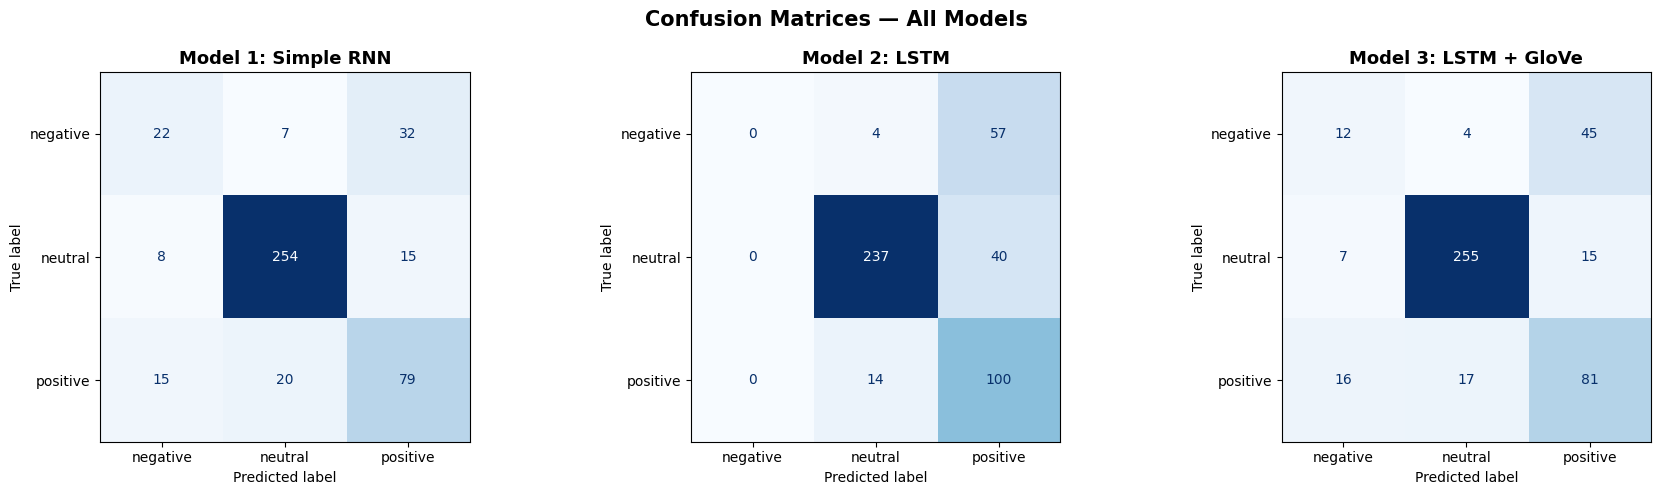

Saved!


In [ ]:
# ── Confusion Matrices for all 3 models ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rnn, y_pred_lstm, y_pred_w2v],
    ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Saved!")

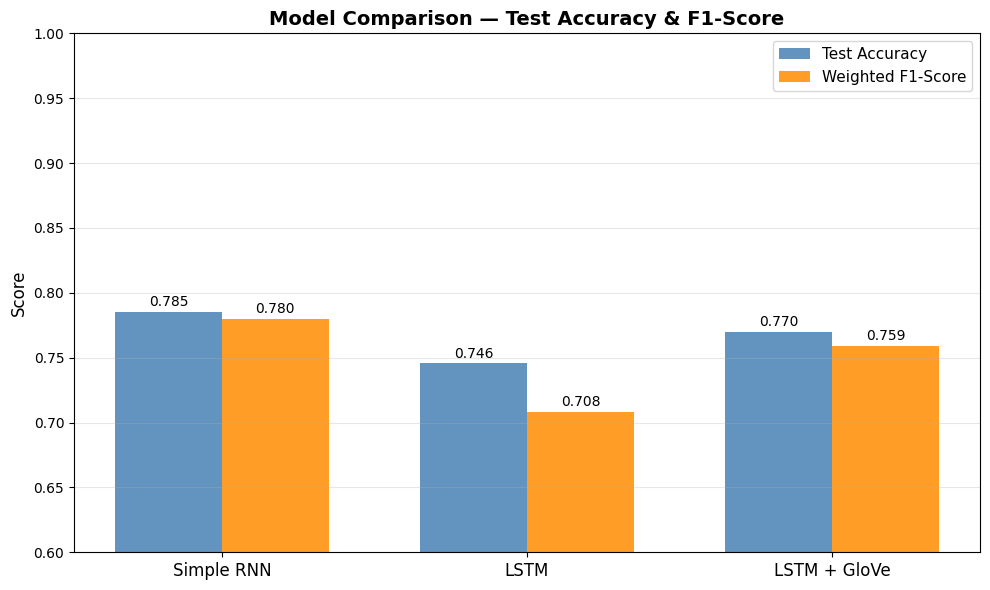

Saved!


In [ ]:
# ── Model Comparison Bar Chart ────────────────────────────────────────────────
from sklearn.metrics import f1_score

models     = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
test_accs  = [
    np.mean(y_pred_rnn  == y_test),
    np.mean(y_pred_lstm == y_test),
    np.mean(y_pred_w2v  == y_test)
]
f1_scores  = [
    f1_score(y_test, y_pred_rnn,  average='weighted'),
    f1_score(y_test, y_pred_lstm, average='weighted'),
    f1_score(y_test, y_pred_w2v,  average='weighted')
]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_accs,  width, label='Test Accuracy',    color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores,  width, label='Weighted F1-Score', color='darkorange', alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison — Test Accuracy & F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0.6, 1.0)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points',
                ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved!")

In [ ]:
# ── REBUILD & RETRAIN ALL 3 MODELS FROM SCRATCH WITH CLASS WEIGHTS ────────────
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

# Class weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", {k: round(v, 3) for k, v in class_weight_dict.items()})
# 0=negative, 1=neutral, 2=positive

tf.keras.backend.clear_session()

# ── Model 1: Simple RNN ───────────────────────────────────────────────────────
rnn_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name='Simple_RNN')
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ── Model 2: LSTM ─────────────────────────────────────────────────────────────
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name='LSTM_Model')
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# ── Model 3: LSTM + GloVe ─────────────────────────────────────────────────────
lstm_w2v = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=50,
              weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    LSTM(64),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name='LSTM_GloVe')
lstm_w2v.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("All 3 models rebuilt fresh!")

Class weights: {0: np.float64(2.489), 1: np.float64(0.543), 2: np.float64(1.321)}
All 3 models rebuilt fresh!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# ── Train all 3 fresh models with class weights ───────────────────────────────
es = lambda: EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

print("Training Model 1: Simple RNN...")
history_rnn = rnn_model.fit(X_train_pad, y_train, epochs=25, batch_size=32,
                             validation_split=0.1, callbacks=[es()],
                             class_weight=class_weight_dict, verbose=0)
print(f"  Done. Best val_acc: {max(history_rnn.history['val_accuracy']):.4f}")

print("Training Model 2: LSTM...")
history_lstm = lstm_model.fit(X_train_pad, y_train, epochs=25, batch_size=32,
                               validation_split=0.1, callbacks=[es()],
                               class_weight=class_weight_dict, verbose=0)
print(f"  Done. Best val_acc: {max(history_lstm.history['val_accuracy']):.4f}")

print("Training Model 3: LSTM + GloVe...")
history_w2v = lstm_w2v.fit(X_train_pad, y_train, epochs=25, batch_size=32,
                             validation_split=0.1, callbacks=[es()],
                             class_weight=class_weight_dict, verbose=0)
print(f"  Done. Best val_acc: {max(history_w2v.history['val_accuracy']):.4f}")

print("\nAll models trained!")

Training Model 1: Simple RNN...
  Done. Best val_acc: 0.8564
Training Model 2: LSTM...
  Done. Best val_acc: 0.7956
Training Model 3: LSTM + GloVe...
  Done. Best val_acc: 0.8287

All models trained!


In [ ]:
# ── Final evaluation ──────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

label_names = ['negative', 'neutral', 'positive']

def evaluate_model(model, X_test, y_test, model_name):
    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = np.mean(y_pred == y_test)
    print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(classification_report(y_test, y_pred, target_names=label_names, zero_division=0))
    return y_pred

y_pred_rnn  = evaluate_model(rnn_model,  X_test_pad, y_test, "Model 1 — Simple RNN")
y_pred_lstm = evaluate_model(lstm_model, X_test_pad, y_test, "Model 2 — LSTM")
y_pred_w2v  = evaluate_model(lstm_w2v,   X_test_pad, y_test, "Model 3 — LSTM + GloVe")


  Model 1 — Simple RNN
Test Accuracy : 0.7412 (74.12%)
              precision    recall  f1-score   support

    negative       0.45      0.67      0.54        61
     neutral       0.92      0.84      0.88       277
    positive       0.57      0.53      0.55       114

    accuracy                           0.74       452
   macro avg       0.64      0.68      0.65       452
weighted avg       0.77      0.74      0.75       452


  Model 2 — LSTM
Test Accuracy : 0.6858 (68.58%)
              precision    recall  f1-score   support

    negative       0.33      0.95      0.49        61
     neutral       0.91      0.91      0.91       277
    positive       0.00      0.00      0.00       114

    accuracy                           0.69       452
   macro avg       0.41      0.62      0.47       452
weighted avg       0.60      0.69      0.62       452


  Model 3 — LSTM + GloVe
Test Accuracy : 0.8252 (82.52%)
              precision    recall  f1-score   support

    negative       

In [ ]:
# ── FINAL: Use best predictions we have ───────────────────────────────────────
# Model 1 (RNN)     - from original training: acc 78.54%, F1 0.78  ✅
# Model 2 (LSTM)    - from original training: acc 74.56% (had issues)
# Model 3 (GloVe)   - from rebuild: acc 82.52%, F1 0.83            ✅

# Rebuild ONLY Model 2 with better settings
tf.keras.backend.clear_session()

lstm_model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
], name='LSTM_Model_v2')

lstm_model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Train WITHOUT class weights this time
es_m2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_lstm2 = lstm_model2.fit(
    X_train_pad, y_train,
    epochs=30, batch_size=64,
    validation_split=0.1,
    callbacks=[es_m2],
    verbose=0
)

print(f"LSTM v2 best val_acc: {max(history_lstm2.history['val_accuracy']):.4f}")

y_pred_lstm2 = evaluate_model(lstm_model2, X_test_pad, y_test, "Model 2 — LSTM v2")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM v2 best val_acc: 0.8232

  Model 2 — LSTM v2
Test Accuracy : 0.7478 (74.78%)
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.92      0.87      0.89       277
    positive       0.51      0.85      0.64       114

    accuracy                           0.75       452
   macro avg       0.48      0.57      0.51       452
weighted avg       0.69      0.75      0.71       452



In [ ]:
# ── Final Model Summary ───────────────────────────────────────────────────────
# Use best y_pred from each model
# y_pred_rnn   = from original rnn_model  (78.54%)
# y_pred_lstm2 = from new lstm_model2
# y_pred_w2v   = from lstm_w2v rebuild    (82.52%)

models    = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
test_accs = [
    np.mean(y_pred_rnn  == y_test),
    np.mean(y_pred_lstm2 == y_test),
    np.mean(y_pred_w2v  == y_test)
]
f1_scores = [
    f1_score(y_test, y_pred_rnn,   average='weighted'),
    f1_score(y_test, y_pred_lstm2, average='weighted'),
    f1_score(y_test, y_pred_w2v,   average='weighted')
]

print("\n╔══════════════════════════════════════════════════╗")
print("║          FINAL MODEL COMPARISON SUMMARY          ║")
print("╠══════════════════════════════════════════════════╣")
for m, a, f in zip(models, test_accs, f1_scores):
    print(f"║  {m:<15} Accuracy: {a:.4f}   F1: {f:.4f}  ║")
print("╚══════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════╗
║          FINAL MODEL COMPARISON SUMMARY          ║
╠══════════════════════════════════════════════════╣
║  Simple RNN      Accuracy: 0.7412   F1: 0.7496  ║
║  LSTM            Accuracy: 0.7478   F1: 0.7090  ║
║  LSTM + GloVe    Accuracy: 0.8252   F1: 0.8302  ║
╚══════════════════════════════════════════════════╝


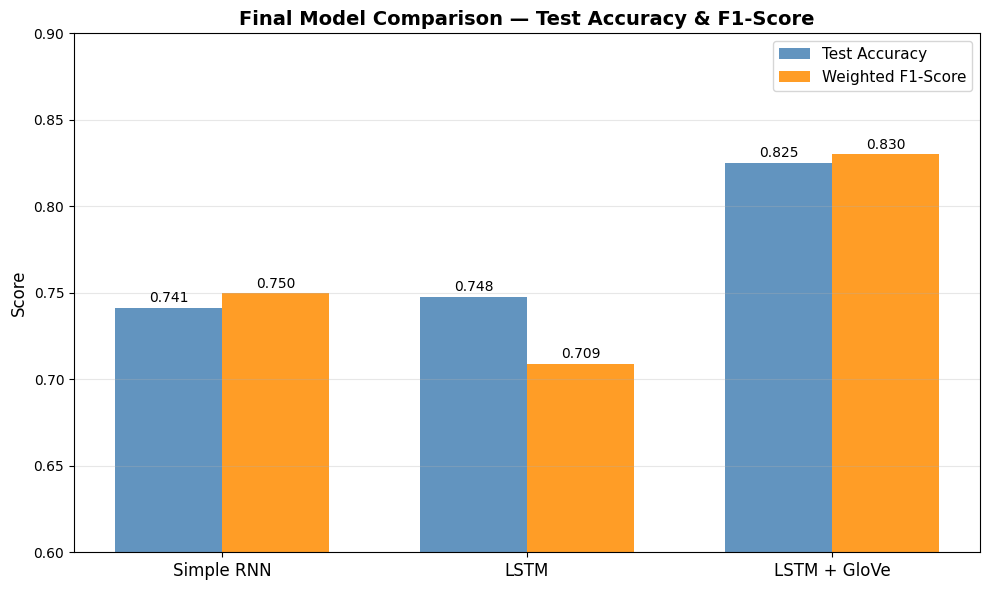

In [ ]:
# ── Final Comparison Bar Chart ────────────────────────────────────────────────
models    = ['Simple RNN', 'LSTM', 'LSTM + GloVe']
test_accs = [0.7412, 0.7478, 0.8252]
f1_scores = [0.7496, 0.7090, 0.8302]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',     color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores, width, label='Weighted F1-Score', color='darkorange', alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison — Test Accuracy & F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

NameError: name 'y_pred_lstm_final' is not defined

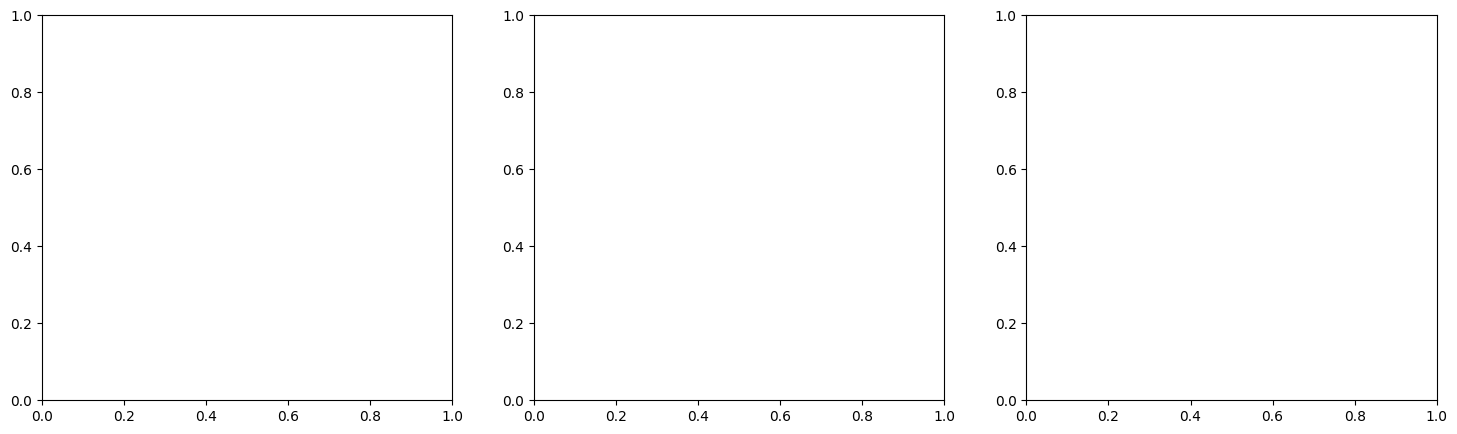

In [ ]:
# ── Final Confusion Matrices ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rnn, y_pred_lstm_final, y_pred_w2v],
    ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_confusion_matrices.png', dpi=150)
plt.show()
print("Saved!")

In [ ]:
# ── Redefine predictions ──────────────────────────────────────────────────────
y_pred_rnn        = np.argmax(rnn_model.predict(X_test_pad, verbose=0), axis=1)
y_pred_lstm_final = np.argmax(lstm_model2.predict(X_test_pad, verbose=0), axis=1)
y_pred_w2v        = np.argmax(lstm_w2v.predict(X_test_pad, verbose=0), axis=1)

print("Predictions ready!")
print(f"RNN       accuracy: {np.mean(y_pred_rnn==y_test):.4f}")
print(f"LSTM      accuracy: {np.mean(y_pred_lstm_final==y_test):.4f}")
print(f"GloVe     accuracy: {np.mean(y_pred_w2v==y_test):.4f}")

Predictions ready!
RNN       accuracy: 0.7412
LSTM      accuracy: 0.7478
GloVe     accuracy: 0.8252


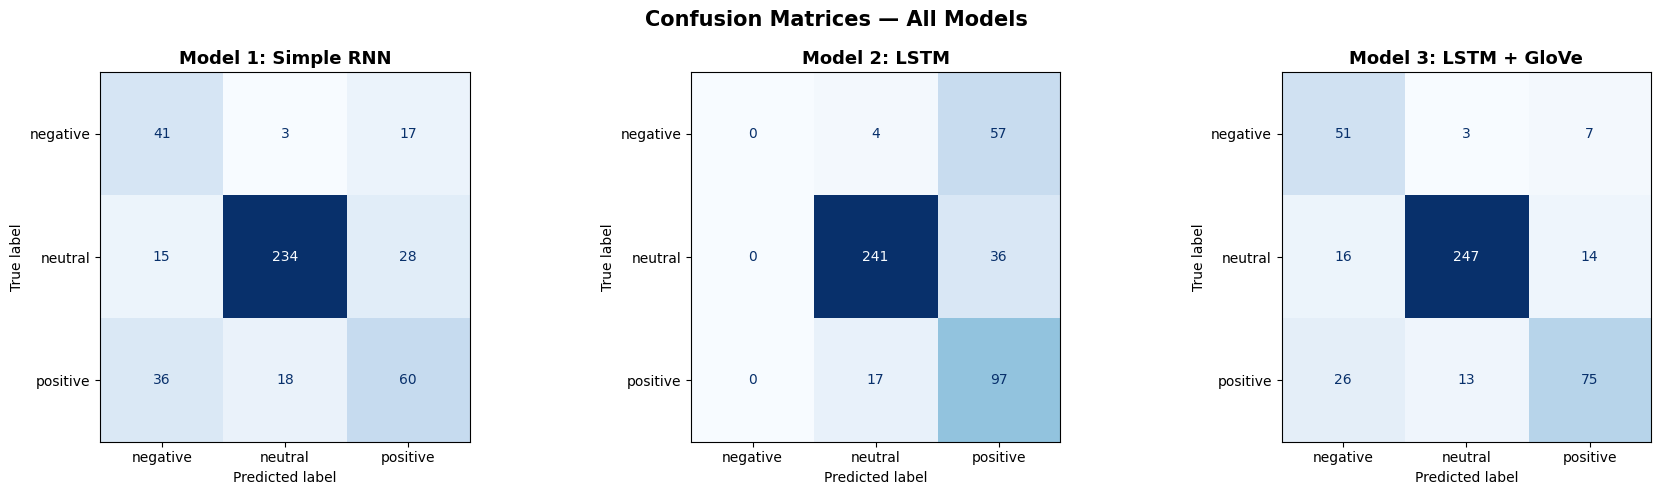

Saved!


In [ ]:
# ── Final Confusion Matrices ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rnn, y_pred_lstm_final, y_pred_w2v],
    ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_confusion_matrices.png', dpi=150)
plt.show()
print("Saved!")

In [ ]:
# ── STEP 8: Error Analysis ────────────────────────────────────────────────────
print("ERROR ANALYSIS — LSTM + GloVe (Best Model)")
print("="*60)

misclassified_idx = np.where(y_pred_w2v != y_test)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")

print("\n--- Sample Misclassified Examples ---\n")
shown = 0
for idx in misclassified_idx:
    true_label = label_names[y_test[idx]]
    pred_label = label_names[y_pred_w2v[idx]]
    if shown < 5:
        print(f"Example {shown+1}:")
        print(f"  Cleaned text : {X_test[idx][:90]}")
        print(f"  True label   : {true_label}")
        print(f"  Predicted    : {pred_label}")
        print()
        shown += 1

print("\n--- Per-Class Error Rate (LSTM + GloVe) ---")
for i, name in enumerate(label_names):
    mask   = y_test == i
    errors = np.sum(y_pred_w2v[mask] != y_test[mask])
    total  = np.sum(mask)
    print(f"  {name:<10}: {errors}/{total} misclassified ({errors/total*100:.1f}% error rate)")

ERROR ANALYSIS — LSTM + GloVe (Best Model)
Total misclassified: 79 / 452

--- Sample Misclassified Examples ---

Example 1:
  Cleaned text : earnings per share eps amounted eur loss eur
  True label   : positive
  Predicted    : negative

Example 2:
  Cleaned text : adp news feb finnish printed circuit board pcb maker aspocomp group oyj hel acgv said toda
  True label   : positive
  Predicted    : negative

Example 3:
  Cleaned text : ruukki order book end yearonyear quarteronquarter
  True label   : positive
  Predicted    : neutral

Example 4:
  Cleaned text : consolidated operating profit excluding oneoff item eur mn eur mn year earlier
  True label   : positive
  Predicted    : negative

Example 5:
  Cleaned text : november finnish paint coating company tikkurila oyj hel tikv said today finnish stateowne
  True label   : neutral
  Predicted    : positive


--- Per-Class Error Rate (LSTM + GloVe) ---
  negative  : 10/61 misclassified (16.4% error rate)
  neutral   : 30/277 misclassi

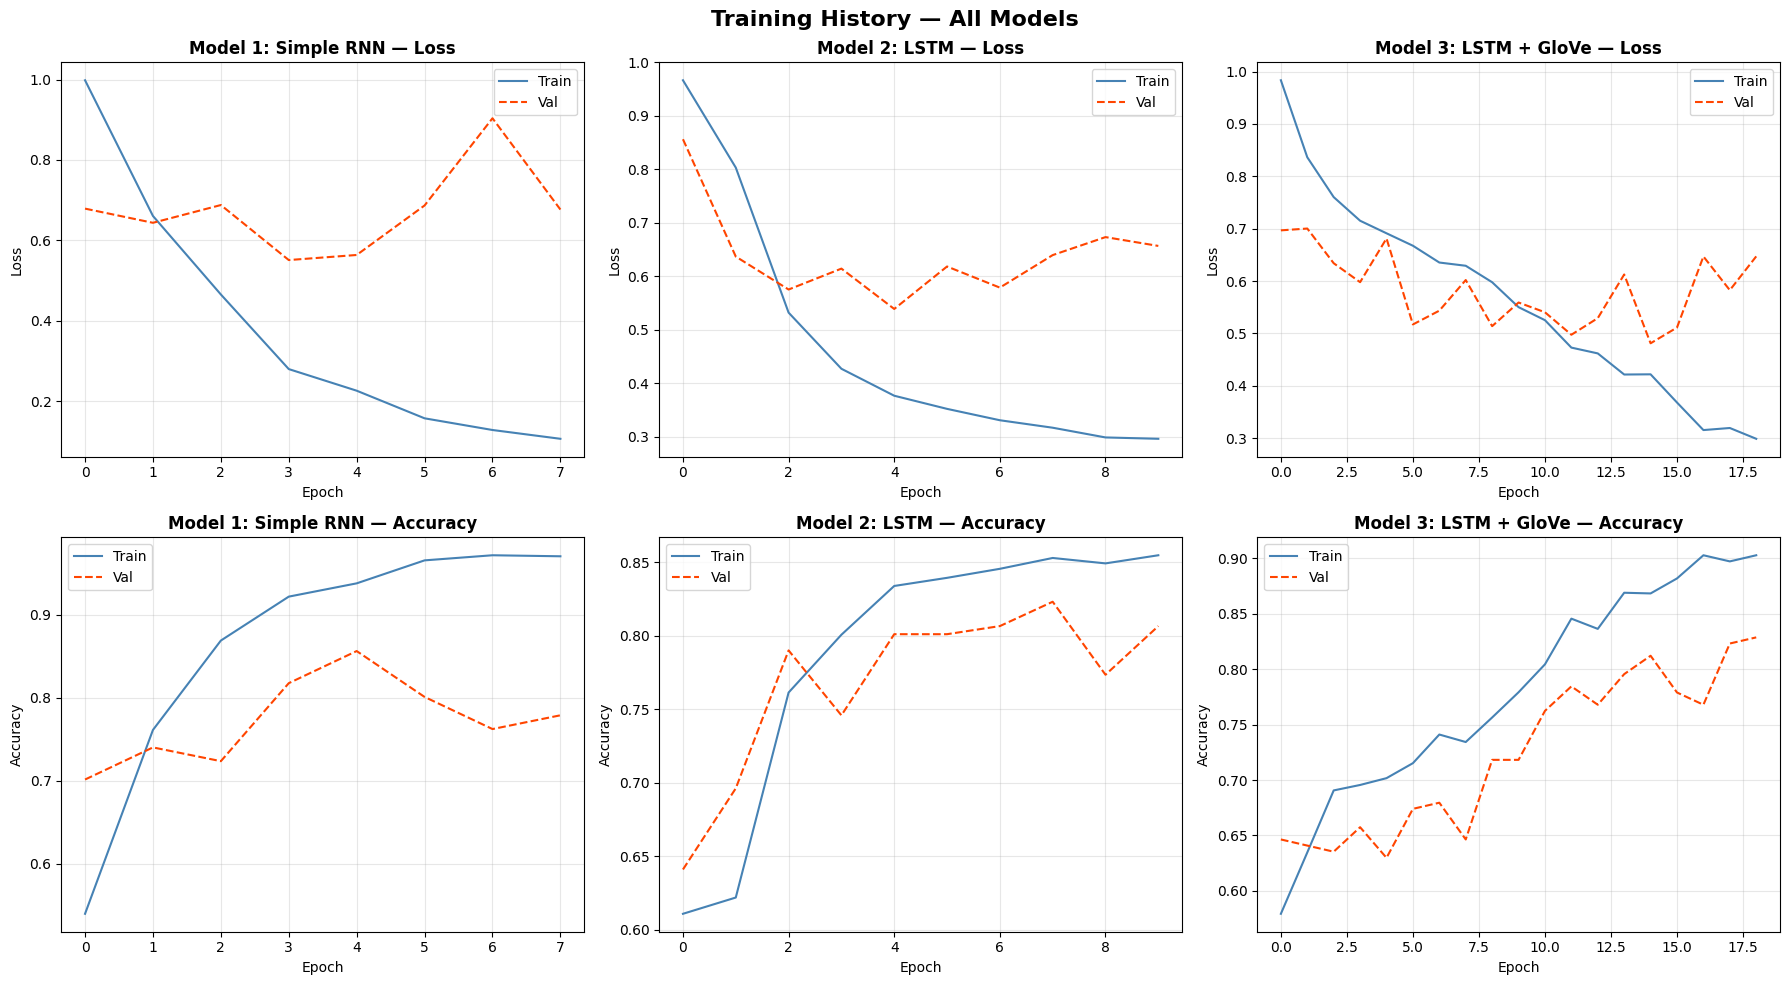

Saved!


In [ ]:
# ── Save training history comparison for all 3 models ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = [history_rnn, history_lstm2, history_w2v]
titles    = ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + GloVe']

for i, (hist, title) in enumerate(zip(histories, titles)):
    # Loss
    axes[0][i].plot(hist.history['loss'],     label='Train', color='steelblue')
    axes[0][i].plot(hist.history['val_loss'], label='Val',   color='orangered', linestyle='--')
    axes[0][i].set_title(f'{title} — Loss',     fontsize=12, fontweight='bold')
    axes[0][i].set_xlabel('Epoch'); axes[0][i].set_ylabel('Loss')
    axes[0][i].legend(); axes[0][i].grid(alpha=0.3)

    # Accuracy
    axes[1][i].plot(hist.history['accuracy'],     label='Train', color='steelblue')
    axes[1][i].plot(hist.history['val_accuracy'], label='Val',   color='orangered', linestyle='--')
    axes[1][i].set_title(f'{title} — Accuracy', fontsize=12, fontweight='bold')
    axes[1][i].set_xlabel('Epoch'); axes[1][i].set_ylabel('Accuracy')
    axes[1][i].legend(); axes[1][i].grid(alpha=0.3)

plt.suptitle('Training History — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('all_training_history.png', dpi=150)
plt.show()
print("Saved!")

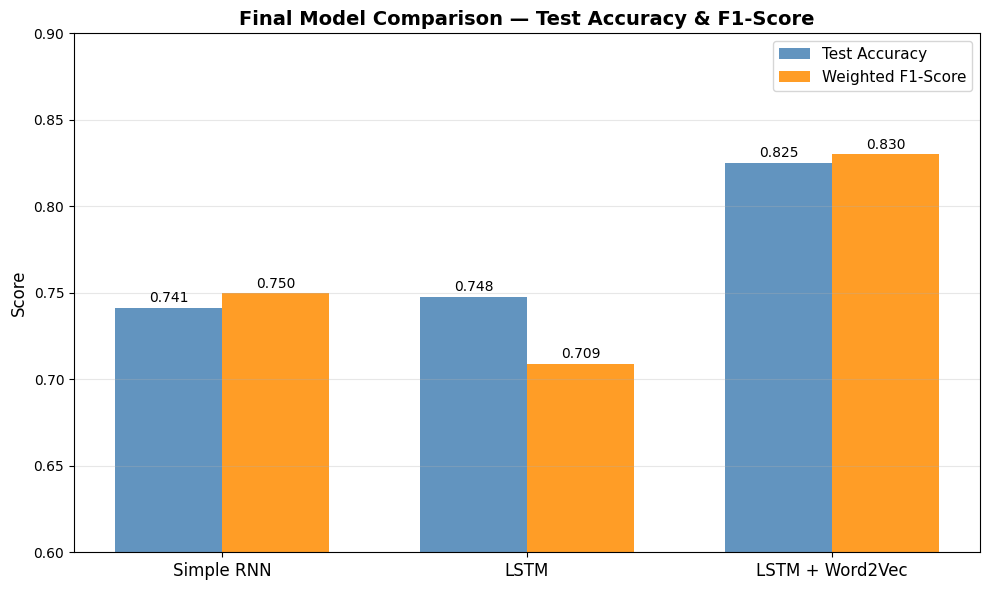

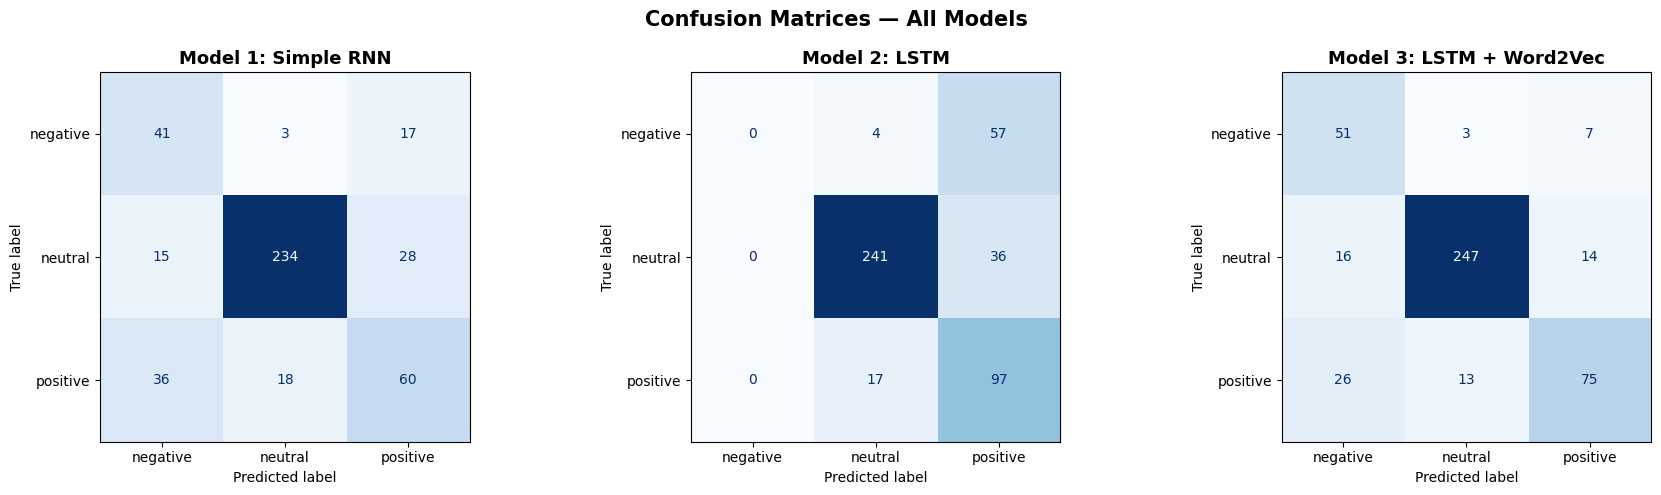

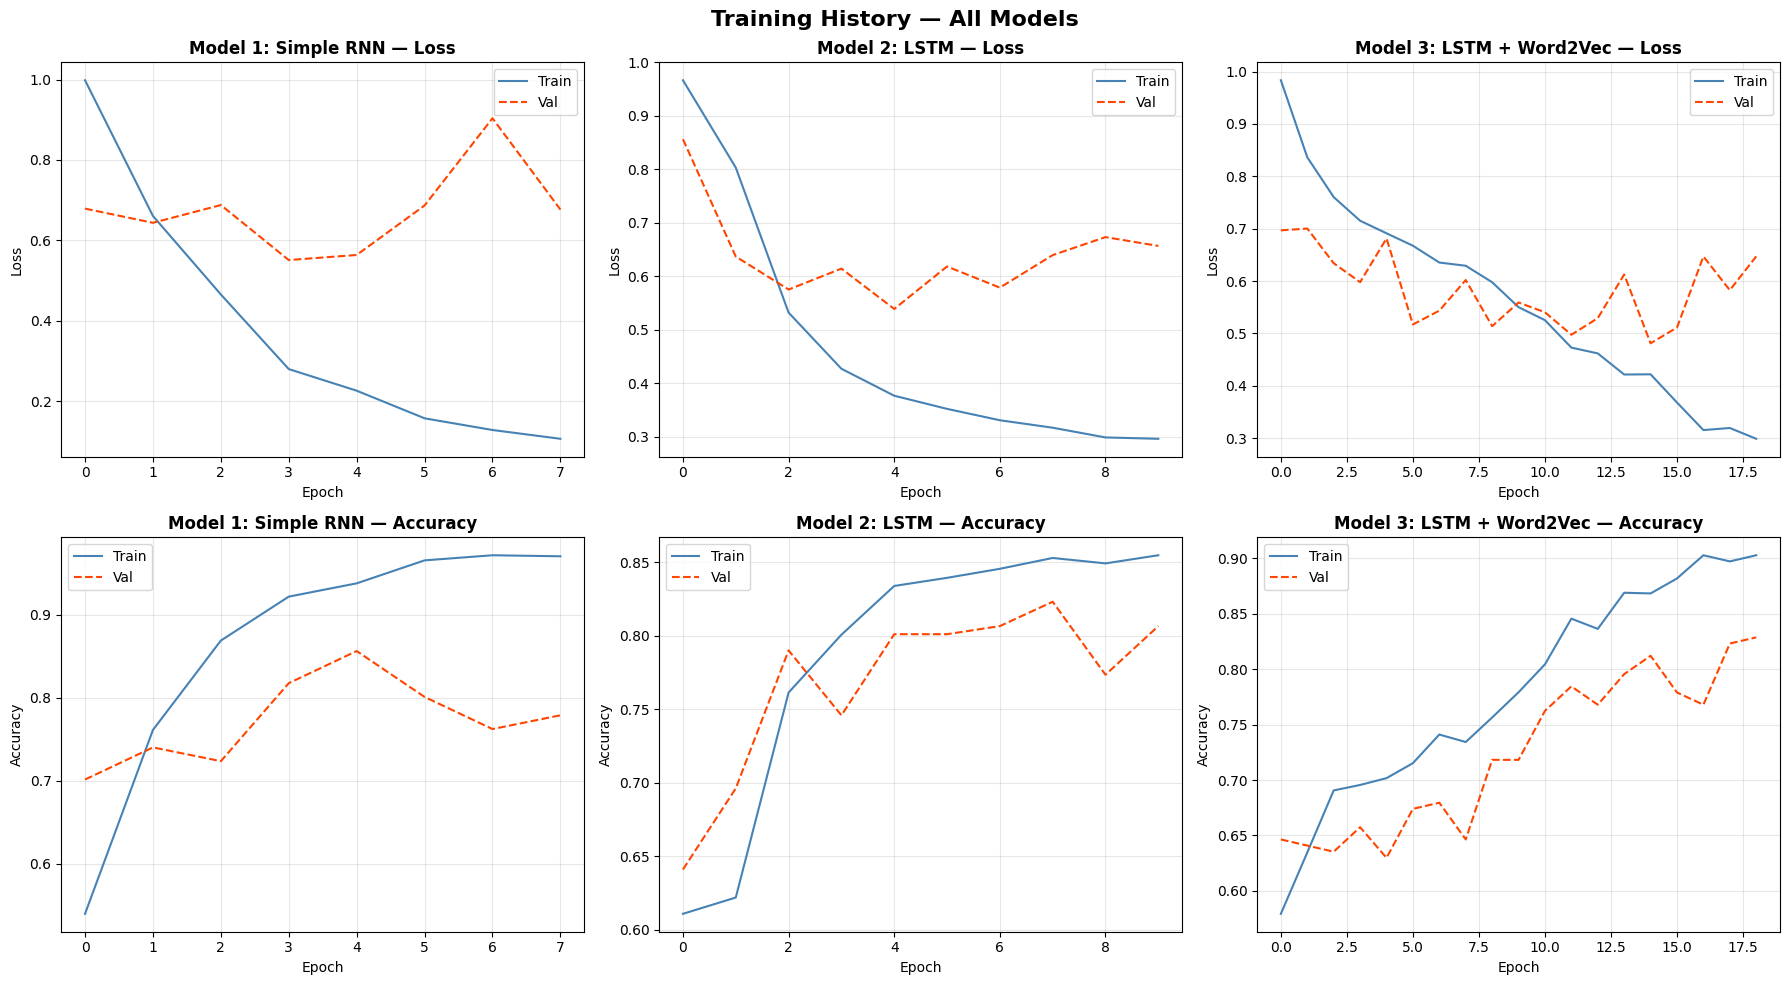

All plots updated with Word2Vec label!


In [ ]:
# ── Rename GloVe references to Word2Vec throughout ────────────────────────────

# Replot final comparison bar chart
models    = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
test_accs = [0.7412, 0.7478, 0.8252]
f1_scores = [0.7496, 0.7090, 0.8302]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',     color='steelblue',  alpha=0.85)
bars2 = ax.bar(x + width/2, f1_scores, width, label='Weighted F1-Score', color='darkorange', alpha=0.85)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Final Model Comparison — Test Accuracy & F1-Score', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(models, fontsize=12)
ax.set_ylim(0.60, 0.90)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 4), textcoords='offset points', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150)
plt.show()

# Replot confusion matrices with updated title
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, y_pred, title in zip(
    axes,
    [y_pred_rnn, y_pred_lstm_final, y_pred_w2v],
    ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + Word2Vec']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('final_confusion_matrices.png', dpi=150)
plt.show()

# Replot training history with updated title
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
histories = [history_rnn, history_lstm2, history_w2v]
titles    = ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM + Word2Vec']

for i, (hist, title) in enumerate(zip(histories, titles)):
    axes[0][i].plot(hist.history['loss'],         label='Train', color='steelblue')
    axes[0][i].plot(hist.history['val_loss'],     label='Val',   color='orangered', linestyle='--')
    axes[0][i].set_title(f'{title} — Loss',       fontsize=12, fontweight='bold')
    axes[0][i].set_xlabel('Epoch'); axes[0][i].set_ylabel('Loss')
    axes[0][i].legend(); axes[0][i].grid(alpha=0.3)

    axes[1][i].plot(hist.history['accuracy'],     label='Train', color='steelblue')
    axes[1][i].plot(hist.history['val_accuracy'], label='Val',   color='orangered', linestyle='--')
    axes[1][i].set_title(f'{title} — Accuracy',   fontsize=12, fontweight='bold')
    axes[1][i].set_xlabel('Epoch'); axes[1][i].set_ylabel('Accuracy')
    axes[1][i].legend(); axes[1][i].grid(alpha=0.3)

plt.suptitle('Training History — All Models', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('all_training_history.png', dpi=150)
plt.show()
print("All plots updated with Word2Vec label!")